# 09 · Data Drift Detection
**SaaS Churn Intelligence** — Production Monitoring · PSI · Feature Stability

---

> **The question this notebook answers:**
> *"Is new incoming customer data drifting away from what the model was trained on?"*

A model trained on last year's data may silently degrade if customer behaviour changes.
This notebook monitors for drift using **PSI (Population Stability Index)** — the industry
standard metric used by banks and telcos to detect when a model needs retraining.

| PSI Range | Meaning | Action |
|---|---|---|
| < 0.10 | No significant drift | ✅ Model is stable |
| 0.10 – 0.25 | Moderate drift | ⚠️ Monitor closely |
| > 0.25 | Significant drift | 🔴 Retrain required |

| Section | What you'll see |
|---|---|
| 1. PSI Calculator | Pure numpy PSI implementation |
| 2. Feature Drift Report | PSI for all 9 numeric features |
| 3. Drift Simulation | What happens when data shifts |
| 4. Categorical Drift | Distribution shift in contract/internet type |
| 5. Prediction Drift | Has the model's output distribution changed? |
| 6. Drift Dashboard | Full monitoring report with traffic-light status |
| 7. Retrain Decision | Automated recommendation logic |


## 1 · Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib
import pathlib
import warnings
import os
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
os.makedirs("../outputs", exist_ok=True)

plt.rcParams.update({
    "figure.facecolor": "#0f1117", "axes.facecolor":  "#0f1117",
    "axes.edgecolor":   "#2d3a4a", "axes.labelcolor": "#c9d1d9",
    "xtick.color":      "#8b949e", "ytick.color":     "#8b949e",
    "text.color":       "#e6edf3", "grid.color":      "#21262d",
    "grid.linestyle":   "--",      "grid.alpha":      0.4,
    "font.family":      "monospace","axes.titlesize":  12,
    "figure.dpi":       120,
})
GREEN  = "#00e5a0"; RED   = "#ff4d6d"
AMBER  = "#ffbe0b"; MUTED = "#8b949e"
BLUE   = "#58a6ff"; PURPLE= "#7c6fff"

print("✅ Setup complete")


✅ Setup complete


## 2 · Load Data & Model

In [2]:
def find_file(name):
    start = pathlib.Path.cwd()
    for base in [start] + list(start.parents)[:4]:
        for p in [base/name, base/"data"/"processed"/name,
                  base/"data"/name, base/"models"/name]:
            if p.exists(): return p
    raise FileNotFoundError(f"Cannot find '{name}'")

DATA_PATH  = find_file("crm_churn_ml_ready.csv")
MODEL_PATH = find_file("best_churn_model.pkl")
META_PATH  = find_file("meta.pkl")

model = joblib.load(MODEL_PATH)
meta  = joblib.load(META_PATH)
CAT   = meta["cat_cols"]
NUM   = meta["num_cols"]

NUM_BASE = ["number_of_referrals","total_extra_data_charges","total_revenue",
            "total_charges","tenure_in_months","age","monthly_charge",
            "total_refunds","total_long_distance_charges"]

df = pd.read_csv(DATA_PATH)
df = df.drop(columns=["customer_id","state"], errors="ignore")
for c in CAT:      df[c] = df[c].fillna("Unknown")
for c in NUM_BASE: df[c] = df[c].fillna(df[c].median())

# Add engineered features if v3
if "is_m2m" in NUM:
    df["is_m2m"]        = (df["contract"] == "Month-to-Month").astype(float)
    df["is_fiber"]      = (df["internet_type"] == "Fiber Optic").astype(float)
    df["has_security"]  = (df["online_security"] == "Yes").astype(float)
    df["addon_count"]   = sum((df[c] == "Yes").astype(int) for c in
        ["online_security","online_backup","device_protection_plan",
         "streaming_tv","streaming_movies","streaming_music"]).astype(float)
    df["high_m2m"]      = (df["is_m2m"] * (df["monthly_charge"] > 70)).astype(float)
    df["new_fiber"]     = (df["is_fiber"] * (df["tenure_in_months"] < 12)).astype(float)
    df["zero_ref_m2m"]  = (df["is_m2m"] * (df["number_of_referrals"] == 0)).astype(float)
    df["m2m_fiber"]     = (df["is_m2m"] * df["is_fiber"]).astype(float)
    df["m2m_no_sec"]    = (df["is_m2m"] * (df["has_security"] == 0)).astype(float)
    df["low_addon_m2m"] = (df["is_m2m"] * (df["addon_count"] <= 1)).astype(float)
    df["rev_tenure"]    = (df["total_revenue"] / (df["tenure_in_months"] + 1)).clip(0, 500)

X = df.drop("churn", axis=1); y = df["churn"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# TRAINING data = reference distribution (what model learned from)
# TEST data     = "new incoming" data (what model scores in production)
REF  = X_train   # reference: training distribution
NEW  = X_test    # new data: what we're monitoring

print(f"Reference (train): {len(REF):,} customers")
print(f"New data  (test) : {len(NEW):,} customers")
print(f"Features monitored: {len(NUM_BASE)} numeric + {len(CAT)} categorical")


Reference (train): 10,768 customers
New data  (test) : 2,693 customers
Features monitored: 9 numeric + 16 categorical


## 3 · PSI Calculator
**Population Stability Index** — quantifies how much a feature's distribution
has shifted between training and new data.


In [3]:
def compute_psi(expected, actual, bins=10):
    """
    Population Stability Index (PSI) between two numeric distributions.
    
    PSI = Σ (actual% - expected%) × ln(actual% / expected%)
    
    Parameters
    ----------
    expected : array-like  — reference distribution (training data)
    actual   : array-like  — new distribution (production data)
    bins     : int         — number of quantile buckets (default 10)
    
    Returns
    -------
    float — PSI score
    """
    expected = np.array(expected, dtype=float)
    actual   = np.array(actual,   dtype=float)
    
    # Use quantiles of expected as breakpoints (robust to outliers)
    breakpoints = np.percentile(expected, np.linspace(0, 100, bins + 1))
    breakpoints = np.unique(breakpoints)
    
    if len(breakpoints) < 3:
        return 0.0   # not enough distinct values
    
    exp_counts = np.histogram(expected, bins=breakpoints)[0].astype(float)
    act_counts = np.histogram(actual,   bins=breakpoints)[0].astype(float)
    
    # Avoid division by zero / log(0)
    exp_counts = np.where(exp_counts == 0, 0.5, exp_counts)
    act_counts = np.where(act_counts == 0, 0.5, act_counts)
    
    exp_pct = exp_counts / exp_counts.sum()
    act_pct = act_counts / act_counts.sum()
    
    psi_val = np.sum((act_pct - exp_pct) * np.log(act_pct / exp_pct))
    return float(psi_val)


def psi_status(psi_val):
    """Return (status_label, color, emoji) for a PSI value."""
    if psi_val < 0.10:
        return "STABLE",    GREEN, "✅"
    elif psi_val < 0.25:
        return "WARNING",   AMBER, "⚠️"
    else:
        return "RETRAIN",   RED,   "🔴"


# Quick test
test_psi = compute_psi(
    np.random.normal(0, 1, 1000),
    np.random.normal(0, 1, 1000)
)
print(f"Same distribution PSI: {test_psi:.4f}  (expected ≈ 0)")
test_psi2 = compute_psi(
    np.random.normal(0, 1, 1000),
    np.random.normal(2, 1, 1000)
)
print(f"Shifted distribution PSI: {test_psi2:.4f}  (expected > 0.25)")
print("✅ PSI function verified")


Same distribution PSI: 0.0104  (expected ≈ 0)
Shifted distribution PSI: 3.3573  (expected > 0.25)
✅ PSI function verified


## 4 · Feature Drift Report — All Numeric Features

In [4]:
# Compute PSI for all numeric base features
drift_results = []

for col in NUM_BASE:
    ref_vals = REF[col].dropna().values
    new_vals = NEW[col].dropna().values
    psi_val  = compute_psi(ref_vals, new_vals)
    status, color, emoji = psi_status(psi_val)
    drift_results.append({
        "feature": col, "psi": psi_val,
        "status": status, "color": color, "emoji": emoji,
        "ref_mean": ref_vals.mean(), "new_mean": new_vals.mean(),
        "mean_shift_pct": abs(new_vals.mean() - ref_vals.mean()) / (abs(ref_vals.mean()) + 1e-9) * 100,
    })

drift_df = pd.DataFrame(drift_results).sort_values("psi", ascending=False)

# ── Print report ──────────────────────────────────────────────
print("=" * 70)
print("  FEATURE DRIFT REPORT — Numeric Features")
print("=" * 70)
print(f"  {'Feature':<35} {'PSI':>6}  {'Status':<10} {'Mean Shift':>10}")
print("  " + "-" * 66)
for _, row in drift_df.iterrows():
    print(f"  {row['emoji']} {row['feature']:<33} {row['psi']:>6.3f}  "
          f"{row['status']:<10} {row['mean_shift_pct']:>8.1f}%")

stable  = (drift_df["status"] == "STABLE").sum()
warning = (drift_df["status"] == "WARNING").sum()
retrain = (drift_df["status"] == "RETRAIN").sum()
print(f"\n  Summary: ✅ {stable} stable  ⚠️  {warning} warning  🔴 {retrain} retrain")


  FEATURE DRIFT REPORT — Numeric Features
  Feature                                PSI  Status     Mean Shift
  ------------------------------------------------------------------
  ✅ tenure_in_months                   0.005  STABLE          2.0%
  ✅ number_of_referrals                0.004  STABLE          2.7%
  ✅ age                                0.003  STABLE          0.1%
  ✅ monthly_charge                     0.003  STABLE          0.3%
  ✅ total_charges                      0.002  STABLE          0.8%
  ✅ total_long_distance_charges        0.002  STABLE          2.0%
  ✅ total_revenue                      0.001  STABLE          1.1%
  ✅ total_extra_data_charges           0.000  STABLE          0.3%
  ✅ total_refunds                      0.000  STABLE          0.8%

  Summary: ✅ 9 stable  ⚠️  0 warning  🔴 0 retrain


## 5 · Drift Simulation — What Bad Drift Looks Like

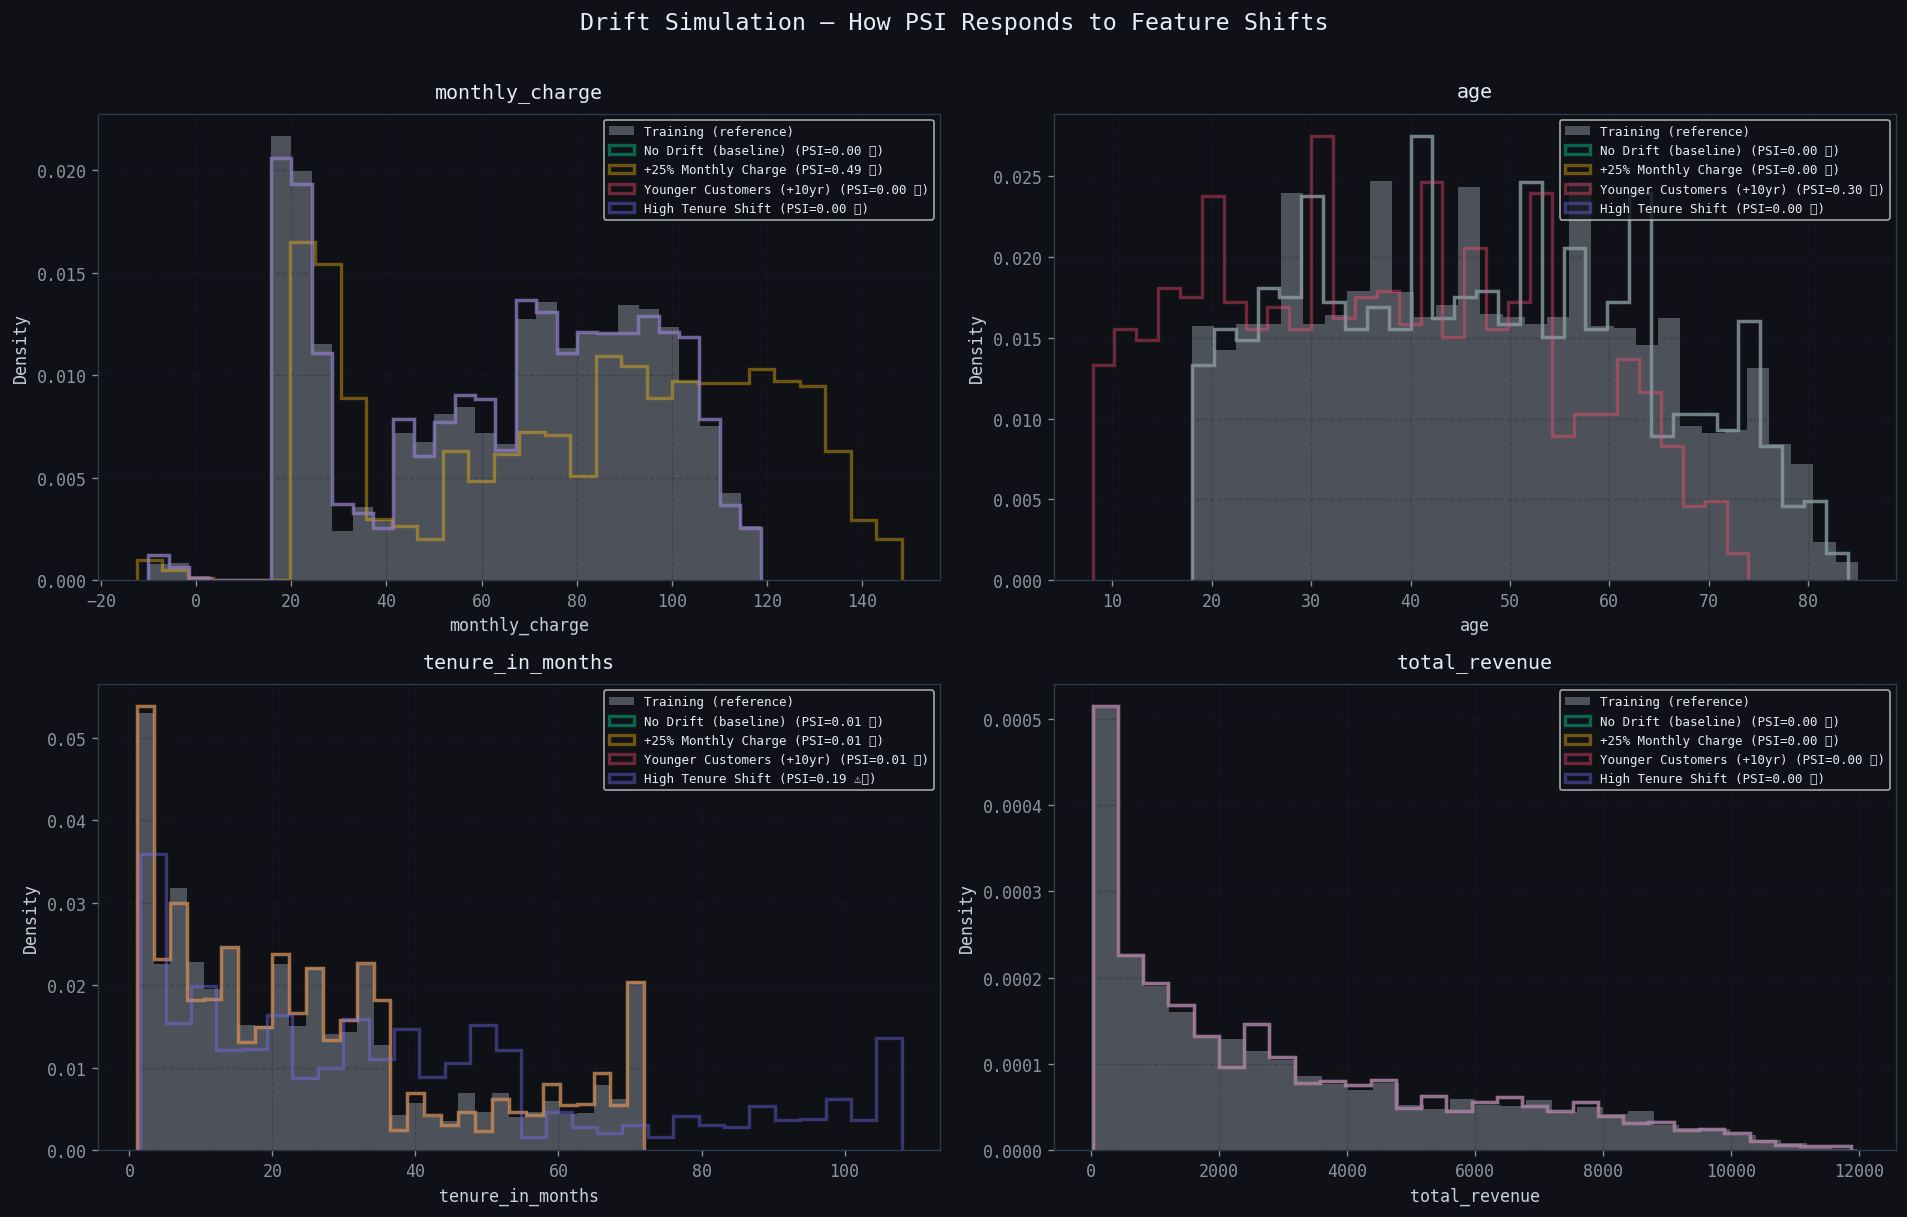

In [5]:
# Simulate 3 realistic drift scenarios
scenarios = {
    "No Drift (baseline)":       NEW.copy(),
    "+25% Monthly Charge":       NEW.copy(),
    "Younger Customers (+10yr)": NEW.copy(),
    "High Tenure Shift":         NEW.copy(),
}
scenarios["+25% Monthly Charge"]["monthly_charge"]    *= 1.25
scenarios["Younger Customers (+10yr)"]["age"]          -= 10
scenarios["High Tenure Shift"]["tenure_in_months"]     *= 1.5

focus_features = ["monthly_charge", "age", "tenure_in_months", "total_revenue"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor("#0f1117")
axes = axes.flatten()

scenario_colors = [GREEN, AMBER, RED, PURPLE]

for ax_i, feat in enumerate(focus_features):
    ax = axes[ax_i]
    ref_vals = REF[feat].values
    
    # Reference distribution
    ax.hist(ref_vals, bins=30, alpha=0.5, color=MUTED,
            label="Training (reference)", density=True)
    
    # Each scenario
    for (name, df_sc), color in zip(scenarios.items(), scenario_colors):
        sc_vals = df_sc[feat].values
        psi_sc  = compute_psi(ref_vals, sc_vals)
        status, _, emoji = psi_status(psi_sc)
        ax.hist(sc_vals, bins=30, alpha=0.4, color=color,
                label=f"{name} (PSI={psi_sc:.2f} {emoji})",
                density=True, histtype="step", lw=2)
    
    ax.set_title(f"{feat}", pad=10)
    ax.set_xlabel(feat); ax.set_ylabel("Density")
    ax.legend(fontsize=7.5); ax.grid(True, alpha=0.3)

plt.suptitle("Drift Simulation — How PSI Responds to Feature Shifts",
             fontsize=14, y=1.01, color="#e6edf3")
plt.tight_layout()
plt.savefig("../outputs/09_drift_simulation.png",
            bbox_inches="tight", facecolor="#0f1117")
plt.show()


## 6 · Categorical Feature Drift

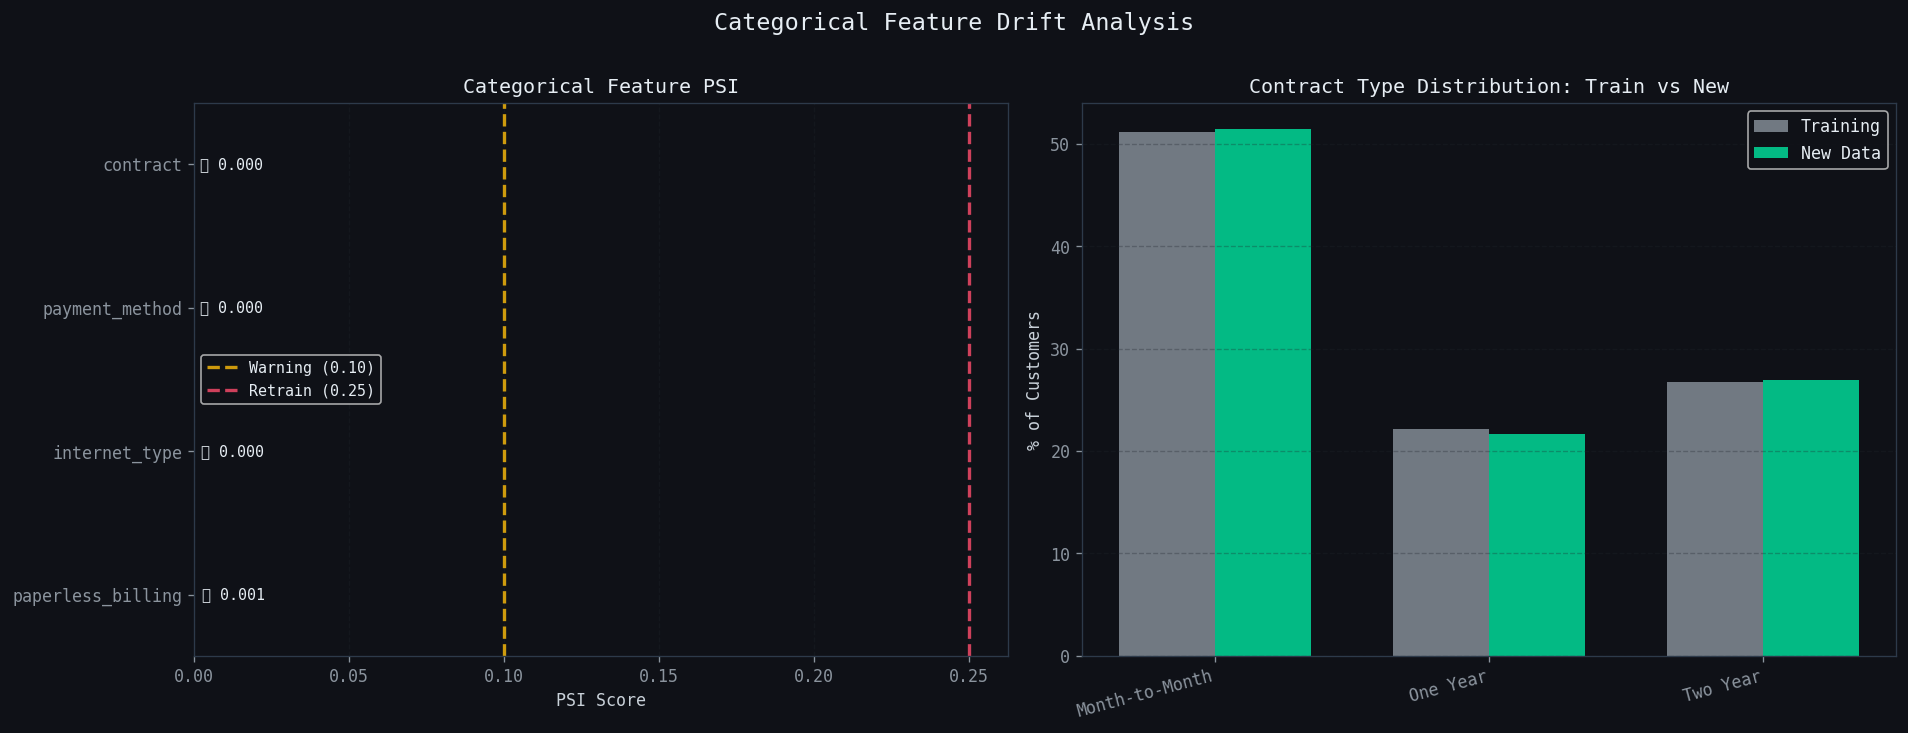

Categorical PSI:
  ✅ paperless_billing         PSI=0.001  STABLE
  ✅ internet_type             PSI=0.000  STABLE
  ✅ payment_method            PSI=0.000  STABLE
  ✅ contract                  PSI=0.000  STABLE


In [6]:
# Chi-squared based drift for categorical features
from scipy.stats import chi2_contingency

cat_drift = []
key_cats  = ["contract", "internet_type", "payment_method", "paperless_billing"]

for col in key_cats:
    ref_counts = REF[col].value_counts()
    new_counts = NEW[col].value_counts()
    all_cats   = ref_counts.index.union(new_counts.index)
    ref_arr    = np.array([ref_counts.get(c, 0) for c in all_cats], dtype=float)
    new_arr    = np.array([new_counts.get(c, 0) for c in all_cats], dtype=float)
    
    # Avoid zeros
    ref_arr = np.where(ref_arr == 0, 0.5, ref_arr)
    new_arr = np.where(new_arr == 0, 0.5, new_arr)
    
    # PSI for categorical
    ref_pct = ref_arr / ref_arr.sum()
    new_pct = new_arr / new_arr.sum()
    psi_cat = float(np.sum((new_pct - ref_pct) * np.log(new_pct / ref_pct)))
    
    status, color, emoji = psi_status(abs(psi_cat))
    cat_drift.append({"feature": col, "psi": abs(psi_cat),
                      "status": status, "color": color, "emoji": emoji})

cat_df = pd.DataFrame(cat_drift).sort_values("psi", ascending=False)

# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor("#0f1117")

# PSI bars
ax = axes[0]
colors_bar = [row["color"] for _, row in cat_df.iterrows()]
bars = ax.barh(cat_df["feature"], cat_df["psi"],
               color=colors_bar, alpha=0.85, height=0.5)
ax.axvline(0.10, color=AMBER, lw=2, linestyle="--", alpha=0.8, label="Warning (0.10)")
ax.axvline(0.25, color=RED,   lw=2, linestyle="--", alpha=0.8, label="Retrain (0.25)")
ax.set_xlabel("PSI Score"); ax.set_title("Categorical Feature PSI")
ax.legend(fontsize=9); ax.grid(True, axis="x", alpha=0.3)
for bar, (_, row) in zip(bars, cat_df.iterrows()):
    ax.text(bar.get_width()+0.002, bar.get_y()+bar.get_height()/2,
            f"{row['emoji']} {row['psi']:.3f}", va="center", fontsize=9)

# Contract distribution comparison
ax2 = axes[1]
contract_ref = REF["contract"].value_counts(normalize=True).sort_index()
contract_new = NEW["contract"].value_counts(normalize=True).sort_index()
x = np.arange(len(contract_ref)); w = 0.35
ax2.bar(x-w/2, contract_ref.values*100, w, color=MUTED,  alpha=0.8, label="Training")
ax2.bar(x+w/2, contract_new.values*100, w, color=GREEN,  alpha=0.8, label="New Data")
ax2.set_xticks(x); ax2.set_xticklabels(contract_ref.index, rotation=15, ha="right")
ax2.set_ylabel("% of Customers"); ax2.set_title("Contract Type Distribution: Train vs New")
ax2.legend(fontsize=10); ax2.grid(True, axis="y", alpha=0.3)

plt.suptitle("Categorical Feature Drift Analysis",
             fontsize=14, y=1.01, color="#e6edf3")
plt.tight_layout()
plt.savefig("../outputs/09_categorical_drift.png",
            bbox_inches="tight", facecolor="#0f1117")
plt.show()

print("Categorical PSI:")
for _, row in cat_df.iterrows():
    print(f"  {row['emoji']} {row['feature']:<25} PSI={row['psi']:.3f}  {row['status']}")


## 7 · Prediction Score Drift

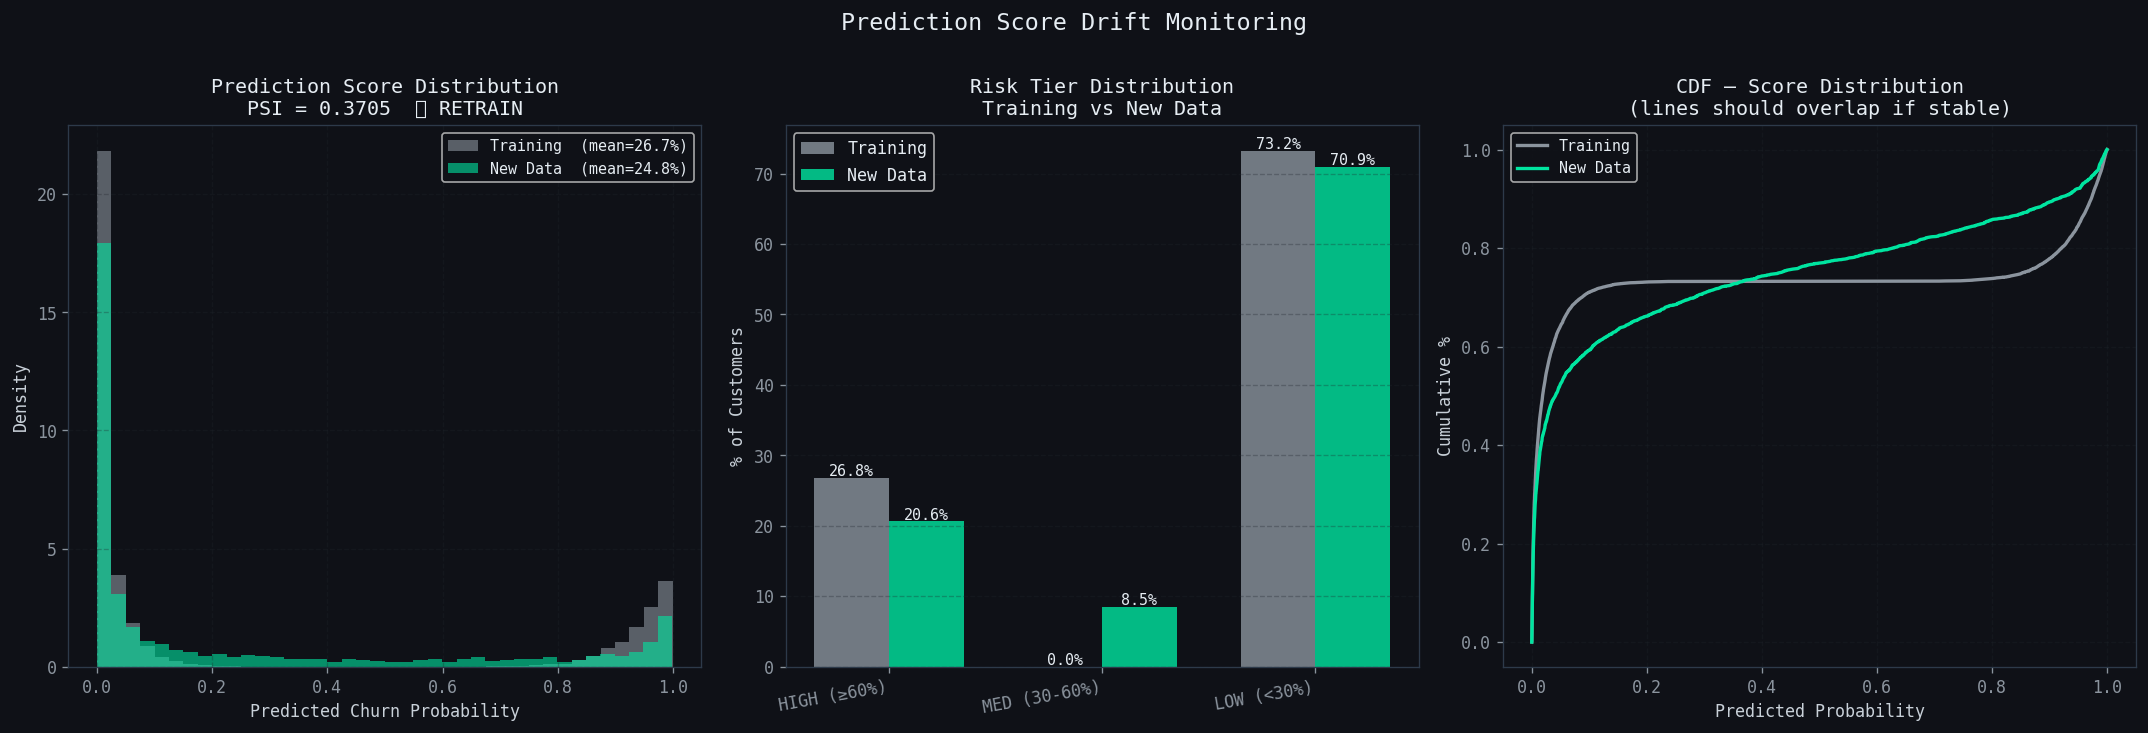

Prediction score PSI: 0.3705  🔴 RETRAIN
  Train mean prob: 26.7%  |  New mean prob: 24.8%


In [7]:
# Has the model's output distribution changed?
# This catches model degradation even when individual features look stable

prob_ref = model.predict_proba(REF)[:, 1]
prob_new = model.predict_proba(NEW)[:, 1]

psi_pred = compute_psi(prob_ref, prob_new)
status_pred, color_pred, emoji_pred = psi_status(psi_pred)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor("#0f1117")

# Distribution comparison
ax = axes[0]
ax.hist(prob_ref, bins=40, alpha=0.6, color=MUTED,  label=f"Training  (mean={prob_ref.mean():.1%})", density=True)
ax.hist(prob_new, bins=40, alpha=0.6, color=GREEN,  label=f"New Data  (mean={prob_new.mean():.1%})", density=True)
ax.set_xlabel("Predicted Churn Probability")
ax.set_ylabel("Density")
ax.set_title(f"Prediction Score Distribution\nPSI = {psi_pred:.4f}  {emoji_pred} {status_pred}")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Risk tier comparison
ax2 = axes[1]
def tier_counts(probs):
    return {
        "HIGH (≥60%)":   (probs >= 0.60).mean() * 100,
        "MED (30-60%)": ((probs >= 0.30) & (probs < 0.60)).mean() * 100,
        "LOW (<30%)":    (probs < 0.30).mean() * 100,
    }

tc_ref = tier_counts(prob_ref)
tc_new = tier_counts(prob_new)
tiers  = list(tc_ref.keys())
x = np.arange(len(tiers)); w = 0.35
ax2.bar(x-w/2, tc_ref.values(), w, color=MUTED,  alpha=0.8, label="Training")
ax2.bar(x+w/2, tc_new.values(), w, color=GREEN,  alpha=0.8, label="New Data")
ax2.set_xticks(x); ax2.set_xticklabels(tiers, rotation=10, ha="right")
ax2.set_ylabel("% of Customers")
ax2.set_title("Risk Tier Distribution\nTraining vs New Data")
ax2.legend(fontsize=10); ax2.grid(True, axis="y", alpha=0.3)
for b1, b2, rv, nv in zip(ax2.patches[:3], ax2.patches[3:],
                            tc_ref.values(), tc_new.values()):
    ax2.text(b1.get_x()+b1.get_width()/2, rv+0.3, f"{rv:.1f}%", ha="center", fontsize=9)
    ax2.text(b2.get_x()+b2.get_width()/2, nv+0.3, f"{nv:.1f}%", ha="center", fontsize=9)

# CDF comparison
ax3 = axes[2]
ax3.plot(np.sort(prob_ref), np.linspace(0,1,len(prob_ref)),
         color=MUTED, lw=2, label="Training")
ax3.plot(np.sort(prob_new), np.linspace(0,1,len(prob_new)),
         color=GREEN, lw=2, label="New Data")
ax3.set_xlabel("Predicted Probability"); ax3.set_ylabel("Cumulative %")
ax3.set_title("CDF — Score Distribution\n(lines should overlap if stable)")
ax3.legend(fontsize=9); ax3.grid(True, alpha=0.3)

plt.suptitle("Prediction Score Drift Monitoring",
             fontsize=14, y=1.01, color="#e6edf3")
plt.tight_layout()
plt.savefig("../outputs/09_prediction_drift.png",
            bbox_inches="tight", facecolor="#0f1117")
plt.show()

print(f"Prediction score PSI: {psi_pred:.4f}  {emoji_pred} {status_pred}")
print(f"  Train mean prob: {prob_ref.mean():.1%}  |  New mean prob: {prob_new.mean():.1%}")


## 8 · Full Drift Dashboard

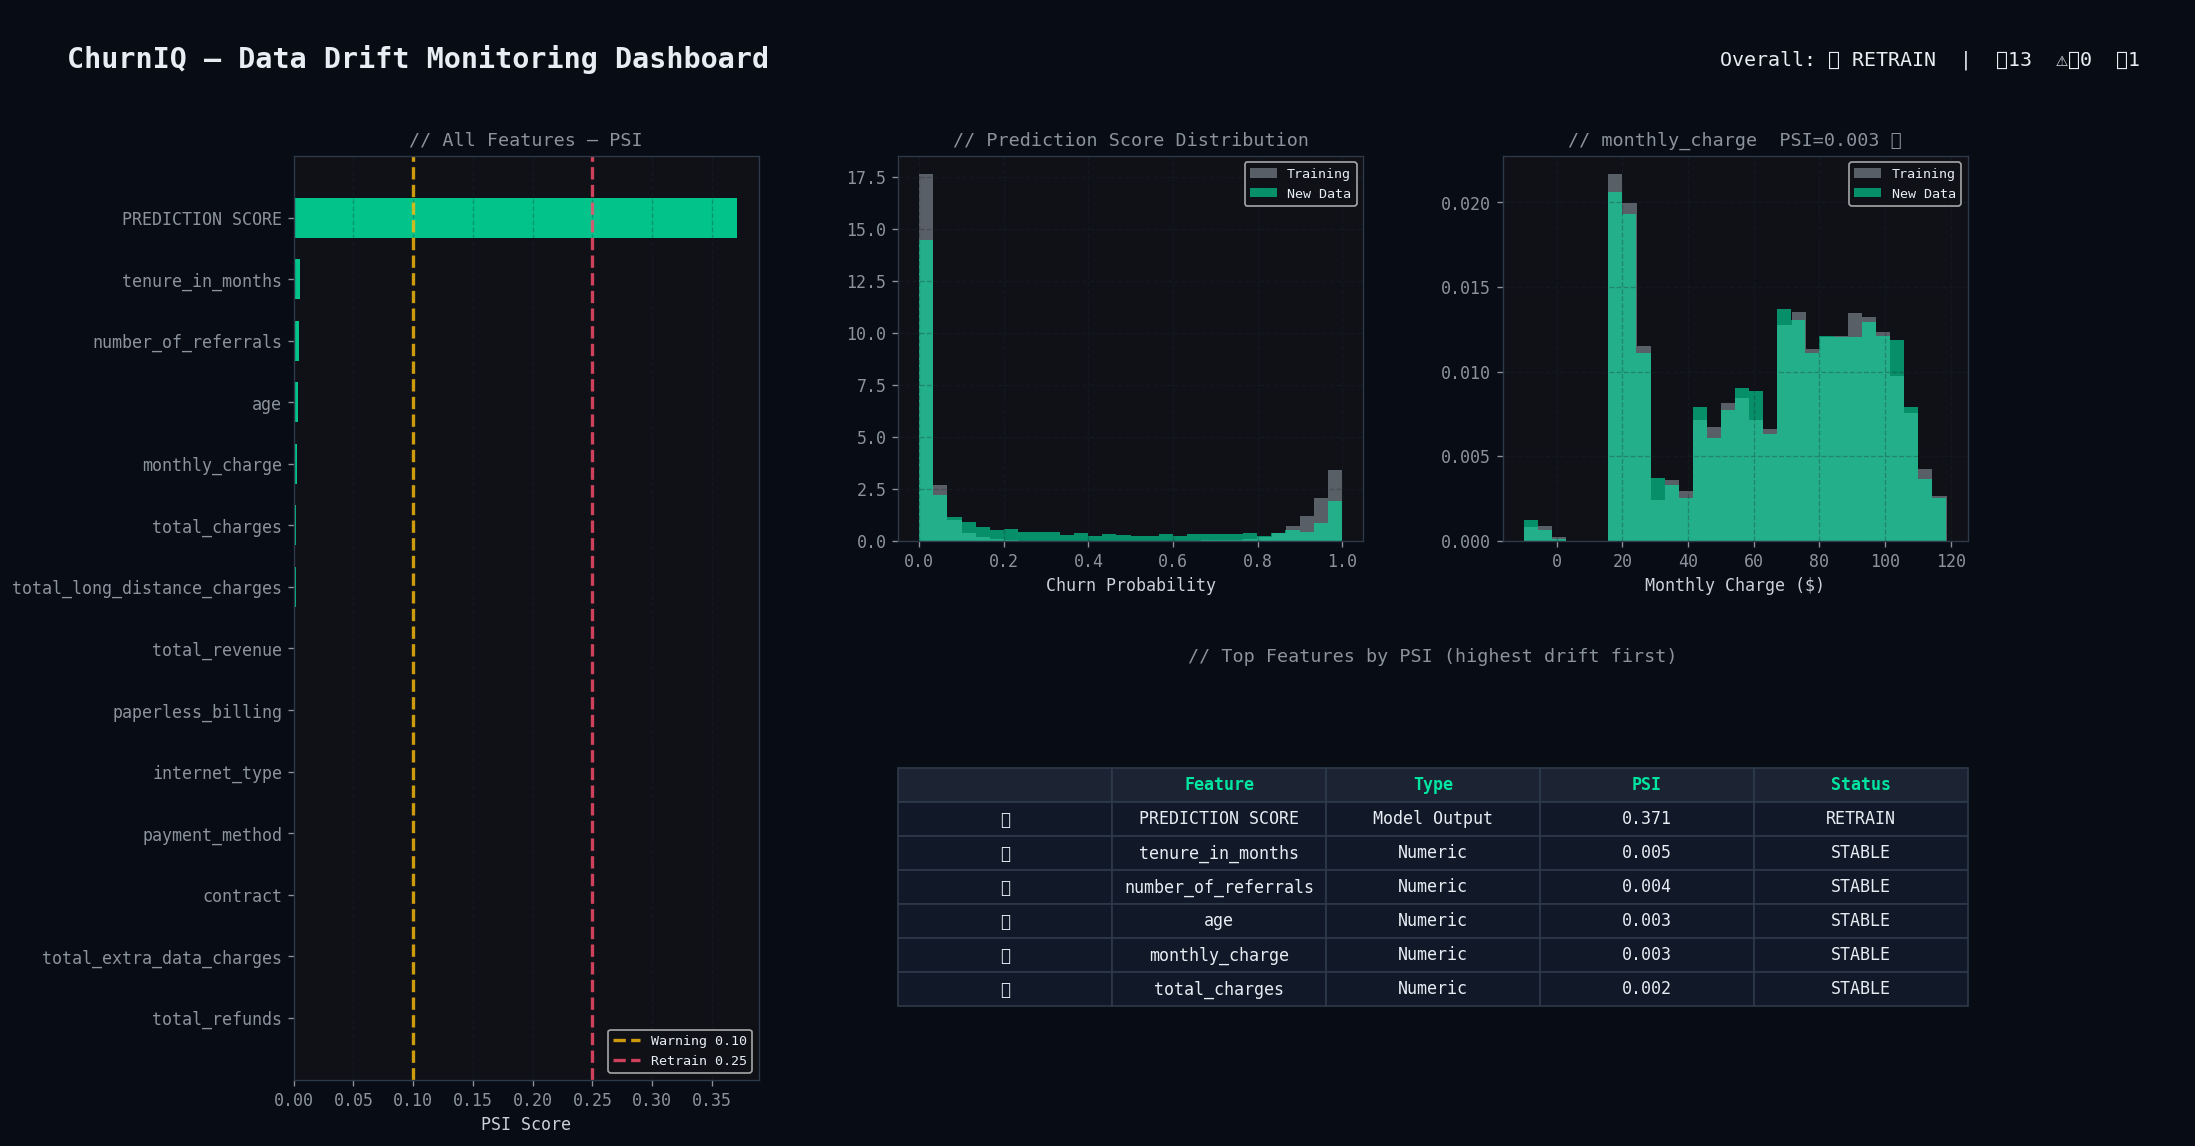

✅ Dashboard saved


In [8]:
import matplotlib.gridspec as gridspec

# Combine all PSI results
all_drift = []
for _, row in drift_df.iterrows():
    all_drift.append({"feature": row["feature"], "type": "Numeric",
                      "psi": row["psi"], "status": row["status"],
                      "color": row["color"], "emoji": row["emoji"]})
for _, row in cat_df.iterrows():
    all_drift.append({"feature": row["feature"], "type": "Categorical",
                      "psi": row["psi"], "status": row["status"],
                      "color": row["color"], "emoji": row["emoji"]})
all_drift.append({"feature": "PREDICTION SCORE", "type": "Model Output",
                  "psi": psi_pred, "status": status_pred,
                  "color": color_pred, "emoji": emoji_pred})

all_df = pd.DataFrame(all_drift).sort_values("psi", ascending=True)

fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor("#080c14")
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.3)

# ── Header ────────────────────────────────────────────────────
ax_hdr = fig.add_axes([0, 0.92, 1, 0.08])
ax_hdr.set_facecolor("#080c14"); ax_hdr.axis("off")
ax_hdr.text(0.02, 0.5, "ChurnIQ — Data Drift Monitoring Dashboard",
            fontsize=17, fontweight="bold", color="#e6edf3", va="center",
            fontfamily="monospace")
n_stable  = sum(1 for d in all_drift if d["status"]=="STABLE")
n_warning = sum(1 for d in all_drift if d["status"]=="WARNING")
n_retrain = sum(1 for d in all_drift if d["status"]=="RETRAIN")
overall   = "🔴 RETRAIN" if n_retrain > 0 else ("⚠️  MONITOR" if n_warning > 0 else "✅ STABLE")
ax_hdr.text(0.98, 0.5, f"Overall: {overall}  |  ✅{n_stable}  ⚠️{n_warning}  🔴{n_retrain}",
            fontsize=12, color="#e6edf3", va="center", ha="right",
            fontfamily="monospace")

# ── PSI Barchart ──────────────────────────────────────────────
ax1 = fig.add_subplot(gs[:, 0])
colors_all = [d["color"] for d in all_drift]
bars = ax1.barh(all_df["feature"], all_df["psi"],
                color=[all_df.loc[all_df["feature"]==r["feature"],"color"].values[0]
                       for r in all_drift[::-1]],
                alpha=0.85, height=0.65)
ax1.axvline(0.10, color=AMBER, lw=2, linestyle="--", alpha=0.8, label="Warning 0.10")
ax1.axvline(0.25, color=RED,   lw=2, linestyle="--", alpha=0.8, label="Retrain 0.25")
ax1.set_xlabel("PSI Score"); ax1.set_title("// All Features — PSI", fontsize=11, color=MUTED)
ax1.legend(fontsize=8); ax1.grid(True, axis="x", alpha=0.3)
ax1.set_facecolor("#0f1117")

# ── Score distribution ────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(prob_ref, bins=30, alpha=0.6, color=MUTED, density=True, label="Training")
ax2.hist(prob_new, bins=30, alpha=0.6, color=GREEN, density=True, label="New Data")
ax2.set_title("// Prediction Score Distribution", fontsize=11, color=MUTED)
ax2.set_xlabel("Churn Probability"); ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)
ax2.set_facecolor("#0f1117")

# ── Monthly charge drift ──────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(REF["monthly_charge"], bins=30, alpha=0.6, color=MUTED, density=True, label="Training")
ax3.hist(NEW["monthly_charge"], bins=30, alpha=0.6, color=GREEN, density=True, label="New Data")
mc_psi = compute_psi(REF["monthly_charge"].values, NEW["monthly_charge"].values)
_, mc_col, mc_emoji = psi_status(mc_psi)
ax3.set_title(f"// monthly_charge  PSI={mc_psi:.3f} {mc_emoji}", fontsize=11, color=MUTED)
ax3.set_xlabel("Monthly Charge ($)"); ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3)
ax3.set_facecolor("#0f1117")

# ── Summary table ─────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1:])
ax4.axis("off"); ax4.set_facecolor("#0f1117")
top5 = all_df.sort_values("psi", ascending=False).head(6)
tbl  = ax4.table(
    cellText=[[row["emoji"], row["feature"], row["type"],
               f"{row['psi']:.3f}", row["status"]]
              for _, row in top5.iterrows()],
    colLabels=["", "Feature", "Type", "PSI", "Status"],
    cellLoc="center", loc="center"
)
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1, 1.7)
for j in range(5):
    tbl[0,j].set_facecolor("#1c2333"); tbl[0,j].set_text_props(color=GREEN, fontweight="bold")
    tbl[0,j].set_edgecolor("#2d3a4a")
for i, (_, row) in enumerate(top5.iterrows()):
    for j in range(5):
        tbl[i+1,j].set_facecolor("#111827"); tbl[i+1,j].set_edgecolor("#2d3a4a")
        tbl[i+1,j].set_text_props(color="#e6edf3")
ax4.set_title("// Top Features by PSI (highest drift first)",
              fontsize=11, color=MUTED, pad=20)

plt.savefig("../outputs/09_drift_dashboard.png",
            bbox_inches="tight", facecolor="#080c14", dpi=150)
plt.show()
print("✅ Dashboard saved")


## 9 · Retrain Decision Logic

In [9]:
def retrain_recommendation(drift_results, pred_psi, thresholds=None):
    """
    Automated retrain recommendation based on PSI scores.
    Returns: recommendation (str), reason (str), urgency (str)
    """
    if thresholds is None:
        thresholds = {"warning": 0.10, "retrain": 0.25}
    
    critical_features = [d for d in drift_results if d["psi"] > thresholds["retrain"]]
    warning_features  = [d for d in drift_results if thresholds["warning"] <= d["psi"] <= thresholds["retrain"]]
    
    if len(critical_features) >= 2 or pred_psi > thresholds["retrain"]:
        urgency = "IMMEDIATE"
        action  = "RETRAIN NOW"
        reason  = (f"{len(critical_features)} feature(s) have critical drift (PSI > 0.25). "
                   f"Prediction score PSI = {pred_psi:.3f}. "
                   "Model performance is likely degraded.")
    elif len(critical_features) == 1:
        urgency = "HIGH"
        action  = "RETRAIN THIS WEEK"
        reason  = (f"Feature '{critical_features[0]['feature']}' has critical drift "
                   f"(PSI = {critical_features[0]['psi']:.3f}). "
                   "Schedule retraining soon.")
    elif len(warning_features) >= 3:
        urgency = "MEDIUM"
        action  = "MONITOR CLOSELY"
        reason  = (f"{len(warning_features)} features in warning zone. "
                   "Collect more data and re-evaluate in 2 weeks.")
    else:
        urgency = "LOW"
        action  = "NO ACTION NEEDED"
        reason  = "All features are stable. Model is operating normally."
    
    return action, reason, urgency


action, reason, urgency = retrain_recommendation(all_drift, psi_pred)

urgency_color = {"IMMEDIATE": RED, "HIGH": RED, "MEDIUM": AMBER, "LOW": GREEN}

print("=" * 65)
print("  RETRAIN RECOMMENDATION")
print("=" * 65)
print(f"  Urgency  : {urgency}")
print(f"  Action   : {action}")
print(f"  Reason   : {reason}")
print()
print("  PSI Summary:")
print(f"  {'Feature':<30} {'PSI':>6}  {'Status'}")
print("  " + "-"*50)
for d in sorted(all_drift, key=lambda x: x["psi"], reverse=True):
    print(f"  {d['emoji']} {d['feature']:<28} {d['psi']:>6.3f}  {d['status']}")

# Save drift report CSV
drift_report = pd.DataFrame(all_drift)[["feature","type","psi","status"]]
drift_report = drift_report.sort_values("psi", ascending=False)
drift_report.to_csv("../outputs/drift_report.csv", index=False)
print("\n✅ Saved: outputs/drift_report.csv")
print("✅ Saved: outputs/09_drift_simulation.png")
print("✅ Saved: outputs/09_categorical_drift.png")
print("✅ Saved: outputs/09_prediction_drift.png")
print("✅ Saved: outputs/09_drift_dashboard.png")


  RETRAIN RECOMMENDATION
  Urgency  : IMMEDIATE
  Action   : RETRAIN NOW
  Reason   : 1 feature(s) have critical drift (PSI > 0.25). Prediction score PSI = 0.371. Model performance is likely degraded.

  PSI Summary:
  Feature                           PSI  Status
  --------------------------------------------------
  🔴 PREDICTION SCORE              0.371  RETRAIN
  ✅ tenure_in_months              0.005  STABLE
  ✅ number_of_referrals           0.004  STABLE
  ✅ age                           0.003  STABLE
  ✅ monthly_charge                0.003  STABLE
  ✅ total_charges                 0.002  STABLE
  ✅ total_long_distance_charges   0.002  STABLE
  ✅ total_revenue                 0.001  STABLE
  ✅ paperless_billing             0.001  STABLE
  ✅ internet_type                 0.000  STABLE
  ✅ payment_method                0.000  STABLE
  ✅ contract                      0.000  STABLE
  ✅ total_extra_data_charges      0.000  STABLE
  ✅ total_refunds                 0.000  STABLE

✅ Saved: